## Imports

In [2]:
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 17.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 917.9/917.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [prophet]m3/4 [prophet]]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

# Facebook's Prophet Library

## Importing the Data

👇 Go to [trends.google.com](https://trends.google.com/trends/?geo=US) and retrieve the dataset representing the interest over time of the keyword `data science` since 2004 in the US. Once you get the dataset, import the data and display the first few rows

In [4]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1GTup48HKTMqT9ZWI02vG65thl7zEBPLK')

## Displaying the Data

👇Visualize the data by displaying the first few rows of the dataframe

In [5]:
df

,Month,data science: (United States)
0,2004-01,17
1,2004-02,13
2,2004-03,11
3,2004-04,6
4,2004-05,6
...,...,...
195,2020-04,82
196,2020-05,80
197,2020-06,78
198,2020-07,77


## Data Preprocessing

Facebook's Prophet library requires the data to be in a specific format

👇 Format the dataset as per Facebook Prophet's requirements. Remember, the DataFrame should have both a `ds` and a `y` column.

In [6]:
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

df.head()

,ds,y
0,2004-01-01,17
1,2004-02-01,13
2,2004-03-01,11
3,2004-04-01,6
4,2004-05-01,6


## Plotting the Data

👇 Plot the data

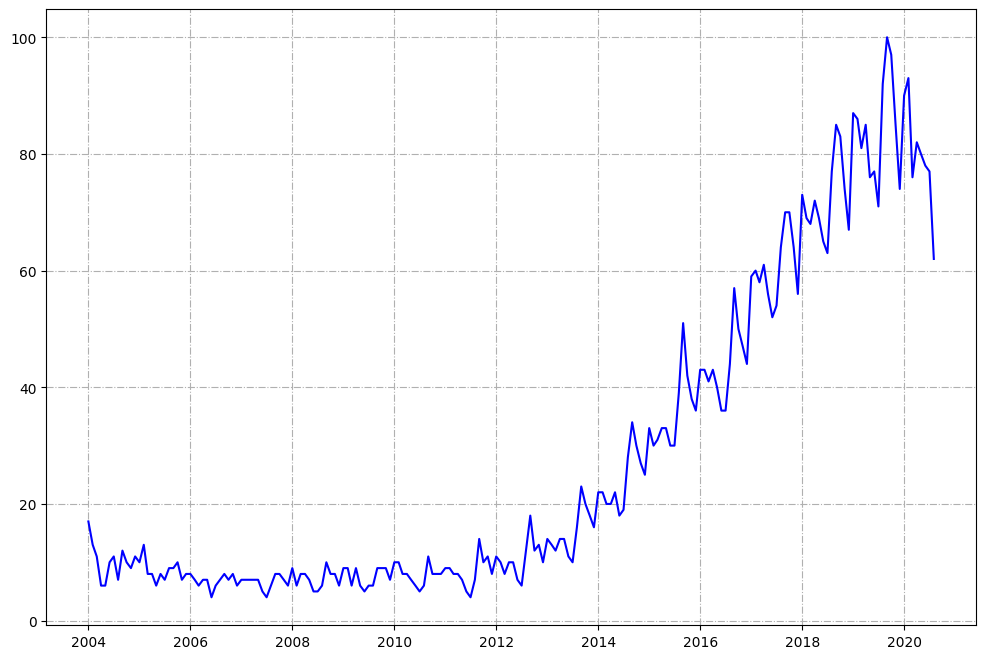

In [7]:
plt.figure(figsize=(12, 8))
plt.grid(linestyle='-.')

plt.plot(df['ds'], df['y'], 'b')
plt.show()

## Fitting the Data

👇 Fit the data using Facebook's Prophet library. Make sure to use a train/test split.

In [8]:
train = df.iloc[:176]
test = df.iloc[176:]

In [9]:
train.shape, test.shape

((176, 2), (24, 2))

In [10]:
train

,ds,y
0,2004-01-01,17
1,2004-02-01,13
2,2004-03-01,11
3,2004-04-01,6
4,2004-05-01,6
...,...,...
171,2018-04-01,72
172,2018-05-01,69
173,2018-06-01,65
174,2018-07-01,63


In [11]:
model = Prophet(seasonality_mode='multiplicative', interval_width=0.95)
model.fit(train)

18:33:59 - cmdstanpy - INFO - Chain [1] start processing
18:33:59 - cmdstanpy - INFO - Chain [1] done processing


## Make Future Predictions

👇Before predicting future values with Facebook's Prophet library, you first need to create a placeholder DataFrame that will eventually hold the predictions. Once you create the DataFrame, try to predict 2 years in the future.

You can create the predictions DataFrame using `make_future_dataframe()`

In [12]:
horizon = 36
future = model.make_future_dataframe(periods=horizon, freq='MS')

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
207,2021-04-01,109.186475,103.085939,115.997208
208,2021-05-01,102.397633,96.592855,109.061852
209,2021-06-01,93.912043,87.660467,100.656360
210,2021-07-01,93.467940,87.233722,99.761431
211,2021-08-01,113.113387,105.319079,121.236543


## Plotting the Forecast

👇 It's time to visualize our forecast. Try to first plot it using [`model.plot(forecast)`](https://facebook.github.io/prophet/docs/quick_start.html)

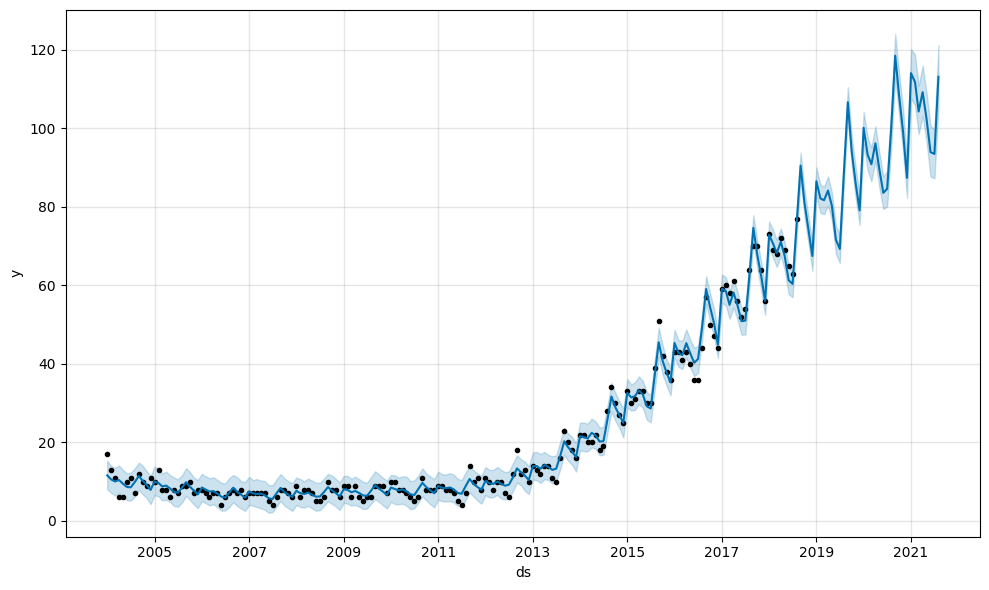

In [13]:
ax = model.plot(forecast);

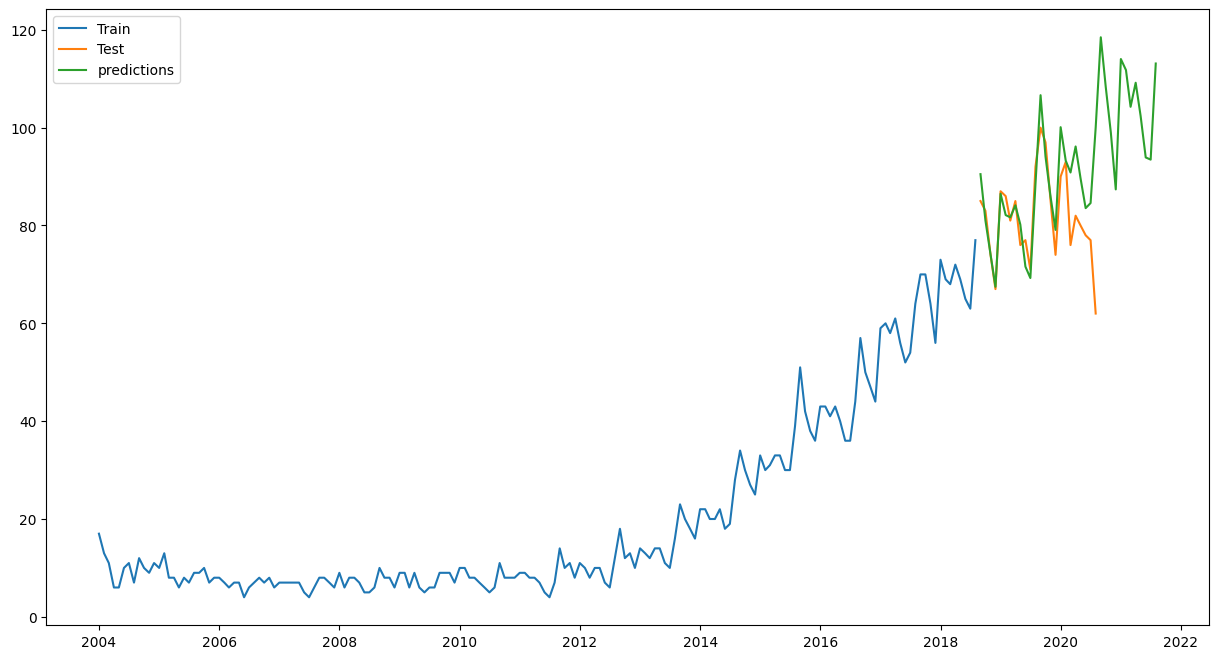

In [14]:
plt.figure(figsize=(15, 8))
plt.plot(train['ds'], train['y'], label="Train")
plt.plot(test['ds'], test['y'], label="Test")
plt.plot(forecast[-horizon:]['ds'], forecast[-horizon:]['yhat'], label="predictions")
plt.legend(loc="best")
plt.show()

👉 From 2004 to 2018 we can see the train data, as well as the forecasted data from 2018 to 2020.

We can also notice a shaded region behind the plot which represents the 95% uncertainty interval.

The black dots represent the original data

## Time Series' Trend and Seasonality

👇 Plot the trend and yearly seasonality of the Time Series. This can be done using the `plot_components()` function from Facebook's Prophet Library

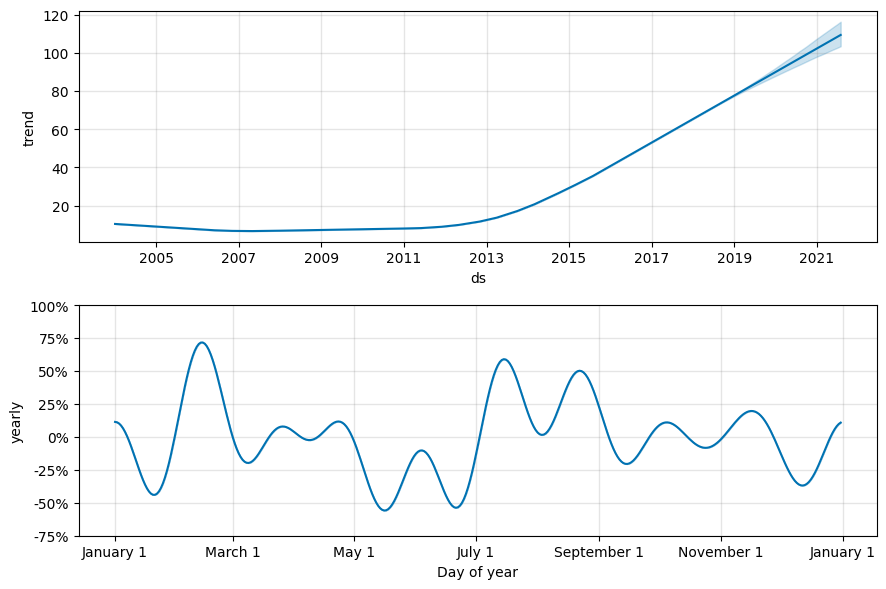

In [15]:
model.plot_components(forecast);

## Evaluating the Model with Cross-Validation!

👇 Using `cross_validation()` and `performance_metrics()` from [prophet.diagnostics](https://facebook.github.io/prophet/docs/diagnostics.html), evaluate the performance of your model

More precisely, create a Time Series K-fold CV with
- train sets of size 5 years
- horizon val sizes of 1 year
- shifting each fold by 180 days

<img src="https://wagon-public-datasets.s3-eu-west-1.amazonaws.com/05-Machine-Learning/09-Time-Series/prophet_train_test_split.png" width=850>

In [16]:
cv_results = cross_validation(model=model, initial=f'{365 * 5} days', horizon='365 days', period='180 days')
cv_results

  0%|          | 0/18 [00:00<?, ?it/s]

18:34:04 - cmdstanpy - INFO - Chain [1] start processing
18:34:04 - cmdstanpy - INFO - Chain [1] done processing
18:34:04 - cmdstanpy - INFO - Chain [1] start processing
18:34:04 - cmdstanpy - INFO - Chain [1] done processing
18:34:04 - cmdstanpy - INFO - Chain [1] start processing
18:34:05 - cmdstanpy - INFO - Chain [1] done processing
18:34:05 - cmdstanpy - INFO - Chain [1] start processing
18:34:05 - cmdstanpy - INFO - Chain [1] done processing
18:34:05 - cmdstanpy - INFO - Chain [1] start processing
18:34:05 - cmdstanpy - INFO - Chain [1] done processing
18:34:05 - cmdstanpy - INFO - Chain [1] start processing
18:34:06 - cmdstanpy - INFO - Chain [1] done processing
18:34:06 - cmdstanpy - INFO - Chain [1] start processing
18:34:06 - cmdstanpy - INFO - Chain [1] done processing
18:34:06 - cmdstanpy - INFO - Chain [1] start processing
18:34:06 - cmdstanpy - INFO - Chain [1] done processing
18:34:06 - cmdstanpy - INFO - Chain [1] start processing
18:34:06 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2009-04-01,5.751318,3.656276,7.903186,9,2009-03-16
1,2009-05-01,5.326924,3.195974,7.301478,6,2009-03-16
2,2009-06-01,5.545936,3.471225,7.759991,5,2009-03-16
3,2009-07-01,5.753378,3.827547,7.780326,6,2009-03-16
4,2009-08-01,5.892882,3.849305,7.737432,6,2009-03-16
...,...,...,...,...,...,...
211,2018-04-01,69.250878,65.958542,72.609427,72,2017-08-01
212,2018-05-01,65.343657,61.805485,68.832141,69,2017-08-01
213,2018-06-01,57.247184,53.772510,60.654551,65,2017-08-01
214,2018-07-01,57.294959,53.787717,60.983043,63,2017-08-01


In [17]:
df_p = performance_metrics(cv_results)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,19.679823,4.436195,3.660699,0.168332,0.140699,0.187116,0.428571
1,40 days,21.432828,4.629560,3.923629,0.179432,0.160026,0.200942,0.380952
2,42 days,19.626451,4.430175,3.748873,0.168842,0.160026,0.186599,0.380952
3,45 days,20.703693,4.550131,3.896479,0.168764,0.160026,0.186505,0.333333
4,46 days,19.029161,4.362243,3.644335,0.161749,0.140699,0.177966,0.380952
...,...,...,...,...,...,...,...,...
165,359 days,36.590470,6.049006,4.776346,0.199105,0.153913,0.235495,0.333333
166,360 days,39.664825,6.298002,5.154145,0.204545,0.153913,0.241338,0.285714
167,361 days,39.350148,6.272970,5.063566,0.201865,0.153913,0.238800,0.309524
168,364 days,39.116990,6.254358,5.020001,0.197903,0.153913,0.235040,0.333333


/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


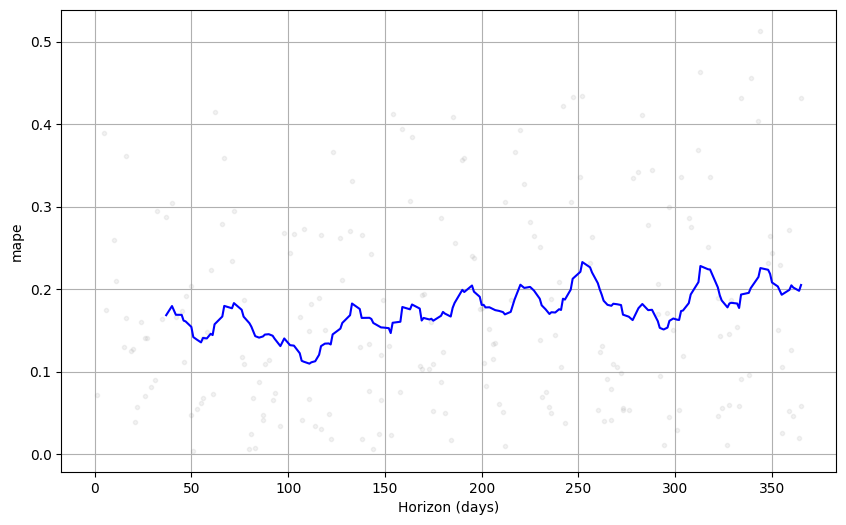

In [18]:
# Plot results below
plot_cross_validation_metric(cv_results, metric='mape');

⚠️ Don't forget to push the challenge to GitHub once you're done 😄